# Notebook 02 — Baseline: Logistic Regression

This notebook trains a TF-IDF + Logistic Regression baseline model on the Sentiment140 dataset.

**Target:** Macro F1 ≥ 0.77

**Steps:**
1. Load preprocessed data
2. TF-IDF vectorization
3. Train Logistic Regression
4. Evaluate: F1, Accuracy, ROC-AUC, Confusion Matrix

In [3]:
!pip install rouge_score

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24971 sha256=9aba684845f07488bce6ec80d4d1b3345fa2554358d38aa39407b358c58a589b
  Stored in directory: c:\users\abdel\appdata\local\pip\cache\wheels\44\af\da\5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge_score


In [4]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import joblib

from preprocess import load_dataset, preprocess_dataframe
from evaluate import print_metrics, plot_confusion_matrix, plot_roc_curve

## 1. Load Data

In [6]:
# Load and preprocess — use sample_size for quick testing, remove for full run
df = load_dataset('training.1600000.processed.noemoticon.csv', sample_size=200000)
print(f'Dataset size: {len(df):,}')
print(df['label'].value_counts())

Dataset size: 200,000
label
1    100143
0     99857
Name: count, dtype: int64


## 2. Train/Validation/Test Split (80/10/10)

In [13]:
print(df.columns.tolist())

['label', 'text']


In [16]:
X = df['text']
y = df['label']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

## 3. TF-IDF Vectorization

In [17]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)
X_test_vec  = tfidf.transform(X_test)
print(f'TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}')

TF-IDF vocabulary size: 50,000


## 4. Train Logistic Regression

In [18]:
model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
model.fit(X_train_vec, y_train)
print('Training complete.')

Training complete.


## 5. Evaluate on Validation Set


  Logistic Regression (Validation) — Evaluation Report
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80      9985
    Positive       0.80      0.81      0.80     10015

    accuracy                           0.80     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.80      0.80      0.80     20000

Matthews Correlation Coefficient (MCC): 0.6045
ROC-AUC Score: 0.8826
Macro F1-Score: 0.8022


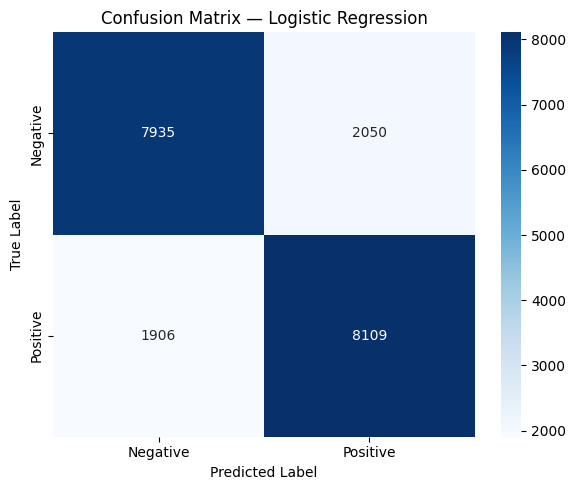

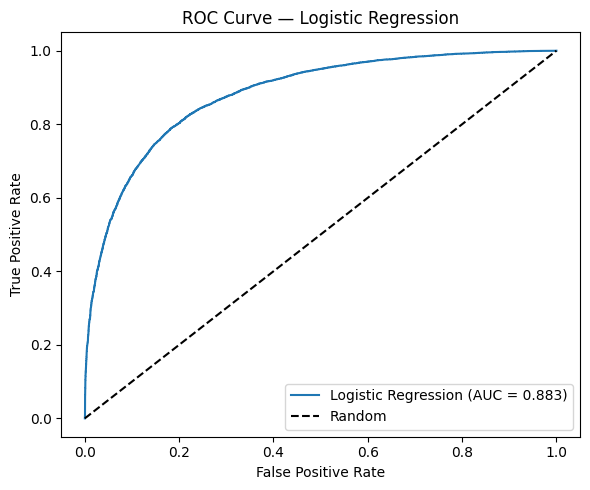

In [21]:
y_val_pred = model.predict(X_val_vec)
y_val_prob = model.predict_proba(X_val_vec)[:, 1]
print_metrics(y_val, y_val_pred, y_val_prob, model_name='Logistic Regression (Validation)')
plot_confusion_matrix(y_val, y_val_pred, model_name='Logistic Regression', save_path=None)
plot_roc_curve(y_val, y_val_prob, model_name='Logistic Regression', save_path=None)

## 6. Final Evaluation on Test Set

In [22]:
y_test_pred = model.predict(X_test_vec)
y_test_prob = model.predict_proba(X_test_vec)[:, 1]
print_metrics(y_test, y_test_pred, y_test_prob, model_name='Logistic Regression (Test)')


  Logistic Regression (Test) — Evaluation Report
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.80      9986
    Positive       0.80      0.81      0.81     10014

    accuracy                           0.81     20000
   macro avg       0.81      0.80      0.80     20000
weighted avg       0.81      0.81      0.80     20000

Matthews Correlation Coefficient (MCC): 0.6100
ROC-AUC Score: 0.8848
Macro F1-Score: 0.8050


## 7. Save Model

In [25]:
joblib.dump(model, 'models/logistic_regression.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
print('Model and vectorizer saved.')

Model and vectorizer saved.
